In [1]:
import pandas as pd

df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print(df.head())
print(df.info())
print(df.describe())
print(df['stroke'].value_counts())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 e

In [2]:
df = df.drop("id", axis=1)

In [3]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

C:\Users\HomePC\AppData\Local\Temp\ipykernel_31584\1439978410.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [4]:
df = pd.get_dummies(df, drop_first=True)

In [5]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score

print("LR Accuracy:",
      accuracy_score(y_test, lr_pred))

print("DT Accuracy:",
      accuracy_score(y_test, dt_pred))

LR Accuracy: 0.952054794520548
DT Accuracy: 0.9481409001956947


In [11]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_pred))

print("DECISION TREE")
print(classification_report(y_test, dt_pred))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022

DECISION TREE
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



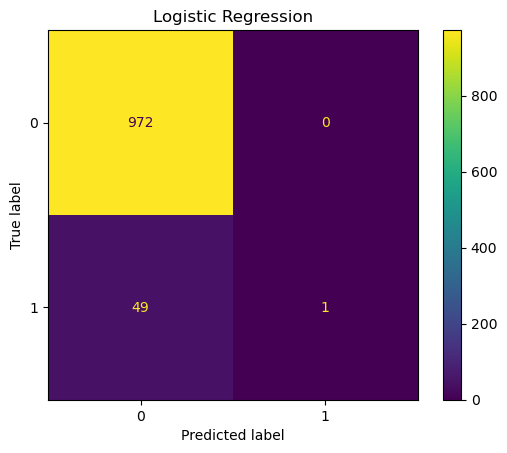

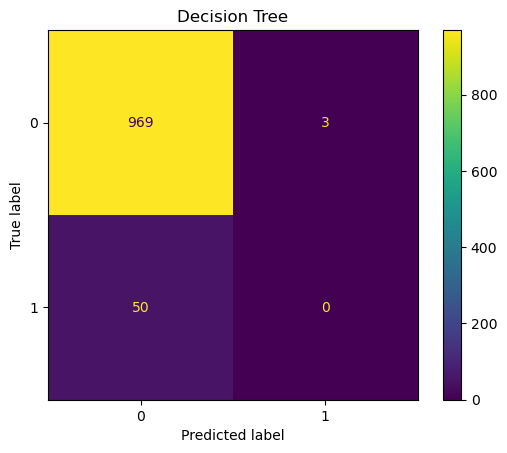

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Logistic Regression")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, dt_pred)
plt.title("Decision Tree")
plt.show()

In [13]:
from sklearn.metrics import roc_auc_score

lr_prob = lr.predict_proba(X_test_scaled)[:,1]
dt_prob = dt.predict_proba(X_test)[:,1]

print("LR AUC:",
      roc_auc_score(y_test, lr_prob))

print("DT AUC:",
      roc_auc_score(y_test, dt_prob))

LR AUC: 0.8422427983539095
DT AUC: 0.8225514403292181


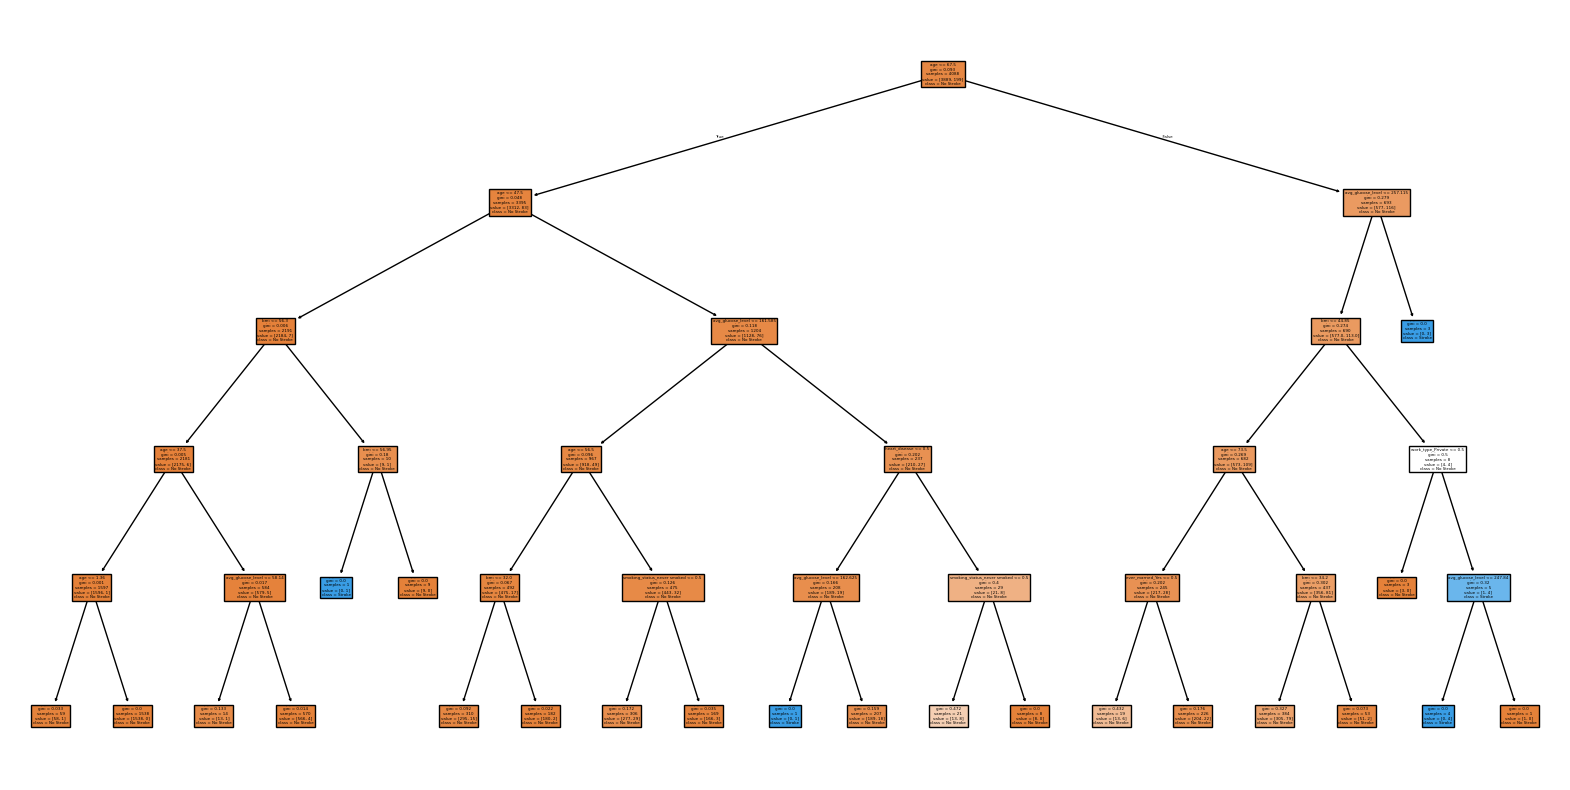

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    filled=True,
    feature_names=X.columns,
    class_names=["No Stroke","Stroke"]
)

plt.show()

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                        Feature  Importance
0                           age    0.559666
3             avg_glucose_level    0.162278
4                           bmi    0.121044
14  smoking_status_never smoked    0.053175
9             work_type_Private    0.042925
2                 heart_disease    0.030996
7              ever_married_Yes    0.029916
1                  hypertension    0.000000
6                  gender_Other    0.000000
5                   gender_Male    0.000000
